,0,1,2,3,4,5,6,7,8,9
ftr,-5.789474,1.578947,-0.526316,7.894737,-4.736842,-8.947368,8.947368,-7.894737,2.631579,4.736842
tgt,63.457390,2.827293,-4.359158,120.863167,43.595667,157.681192,157.987659,123.066223,9.432829,40.043896


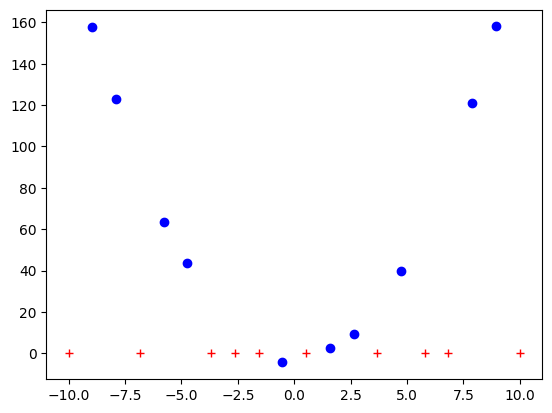

In [2]:
import numpy as np
import sklearn.model_selection as skms
import pandas as pd
import matplotlib.pyplot as plt
N = 20
ftr = np.linspace(-10, 10, num=N) # ftr values
tgt = 2*ftr**2 - 3 + np.random.uniform(-2, 2, N) # tgt = func(ftr)
(train_ftr, test_ftr,
train_tgt, test_tgt) = skms.train_test_split(ftr, tgt, test_size=N//2)
display(pd.DataFrame({"ftr":train_ftr, "tgt":train_tgt}).T)
plt.plot(train_ftr, train_tgt, 'bo')
plt.plot(test_ftr, np.zeros_like(test_ftr), 'r+')

In [3]:
import sklearn.linear_model as linear_model
sk_model = linear_model.LinearRegression()
sk_model.fit(train_ftr.reshape(-1, 1), train_tgt)
sk_preds = sk_model.predict(test_ftr.reshape(-1, 1))
sk_preds[:3]

array([72.25638225, 77.15955977, 69.19189629])

In [4]:
model_one = np.poly1d(np.polyfit(train_ftr, train_tgt, 1))
preds_one = model_one(test_ftr)
print(preds_one[:3])

[72.25638225 77.15955977 69.19189629]


In [5]:
from sklearn import metrics
# da li su predikcije iste ?
print("Isto?", np.allclose(sk_preds, preds_one))
# and we can still use sklearn to evaluate it
mse = metrics.mean_squared_error
print("RMSE:", np.sqrt(mse(test_tgt, preds_one)))

Isto? True
RMSE: 72.04563450617688


In [6]:
model_two = np.poly1d(np.polyfit(train_ftr, train_tgt, 2))
preds_two = model_two(test_ftr)
print(preds_one[:3])

[72.25638225 77.15955977 69.19189629]


In [7]:
from sklearn import metrics
# da li su predikcije iste ?
print("Isto?", np.allclose(sk_preds, preds_two))
# and we can still use sklearn to evaluate it
mse = metrics.mean_squared_error
print("RMSE:", np.sqrt(mse(test_tgt, preds_two)))

Isto? False
RMSE: 1.0304462533848118


In [8]:
model_three = np.poly1d(np.polyfit(train_ftr, train_tgt, 9))
preds_three = model_three(test_ftr)
print(preds_three[:3])

[ -1.53936687 101.39144599  20.5308742 ]


In [9]:
from sklearn import metrics
# da li su predikcije iste ?
print("Isto?", np.allclose(sk_preds, preds_three))
# and we can still use sklearn to evaluate it
mse = metrics.mean_squared_error
print("RMSE:", np.sqrt(mse(test_tgt, preds_three)))

Isto? False
RMSE: 53.89653548407015


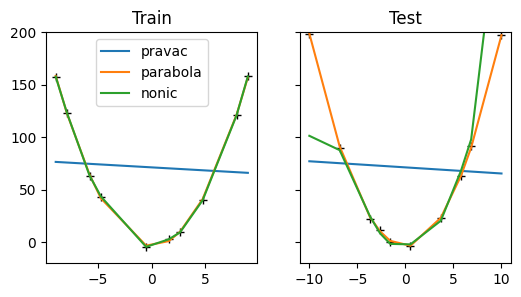

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
labels = ['pravac', 'parabola', 'nonic']
models = [model_one, model_two, model_three]
train = (train_ftr, train_tgt)
test = (test_ftr, test_tgt)
for ax, (ftr, tgt) in zip(axes, [train, test]):
  ax.plot(ftr, tgt, 'k+')
  for m, lbl in zip(models, labels):
    ftr = sorted(ftr)
    ax.plot(ftr, m(ftr), '-', label=lbl)
axes[1].set_ylim(-20, 200)
axes[0].set_title("Train")
axes[1].set_title("Test");
axes[0].legend(loc='upper center');

             Train Error  Test Error
Complexity                          
1           6.002712e+01   72.045635
2           1.067858e+00    1.030446
6           9.177460e-01    2.233695
9           3.887000e-13   53.896535


<Axes: xlabel='Complexity'>

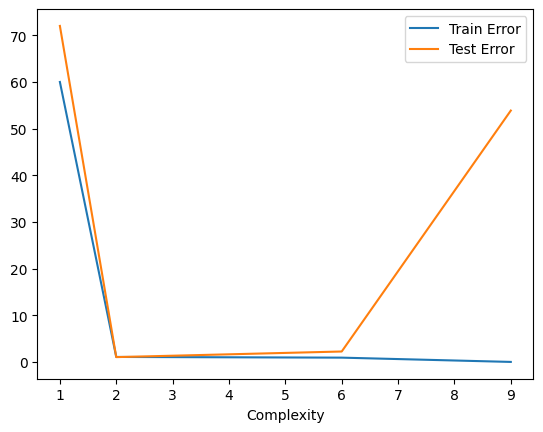

In [13]:
results = []
for complexity in [1, 2, 6, 9]:
  model = np.poly1d(np.polyfit(train_ftr, train_tgt, complexity))
  train_error = np.sqrt(mse(train_tgt, model(train_ftr)))
  test_error = np.sqrt(mse(test_tgt, model(test_ftr)))
  results.append((complexity, train_error, test_error))
columns = ["Complexity", "Train Error", "Test Error"]
results_df = pd.DataFrame.from_records(results,
columns=columns,
index="Complexity")
print(results_df)
results_df.plot()